In [1]:
from pathlib import Path
import json
import zipfile
import pandas as pd

In [2]:
headers_json_path = Path('../headers/headers.json')
headers_zip_path = Path('../headers/headers.zip')
if headers_json_path.exists():
    with headers_json_path.open() as handle:
        headers = json.load(handle)
elif headers_zip_path.exists():
    with zipfile.ZipFile(headers_zip_path) as archive:
        with archive.open('headers.json') as handle:
            headers = json.load(handle)
else:
    raise FileNotFoundError('Expected ../headers/headers.json or ../headers/headers.zip')
df = pd.DataFrame(headers)
df

,hash,bits,time
0,000000000019d6689c085ae165831e934ff763ae46a2a6...,1d00ffff,1231006505
1,00000000839a8e6886ab5951d76f411475428afc90947e...,1d00ffff,1231469665
2,000000006a625f06636b8bb6ac7b960a8d03705d1ace08...,1d00ffff,1231469744
3,0000000082b5015589a3fdf2d4baff403e6f0be035a5d9...,1d00ffff,1231470173
4,000000004ebadb55ee9096c9a2f8880e09da59c0d68b1c...,1d00ffff,1231470988
...,...,...,...
865038,00000000000000000002af876a1d8ce11e1c07018b016a...,17030ecd,1728572242
865039,00000000000000000000445bb08413ba56b56068395864...,17030ecd,1728572873
865040,000000000000000000019ca8e0127b00104b98ef7297e4...,17030ecd,1728573656
865041,0000000000000000000116551169c5d38e6b66b8fe27ab...,17030ecd,1728574093


In [3]:
def bits_to_target(bits):
    """Decode the compact 'bits' field from a Bitcoin block header into a 256-bit target.

    The Bitcoin protocol encodes the proof-of-work target in a 4-byte compact
    representation called 'bits'.  The encoding follows the same convention as
    OpenSSL's MPI format, truncated to three significant bytes:

        bits   = (exponent << 24) | mantissa
        target = mantissa << (8 * (exponent - 3))

    where ``exponent`` is the most-significant byte and ``mantissa`` is the
    remaining three bytes.

    Parameters
    ----------
    bits : int or str
        The compact target value.  Accepted as a plain integer or as a
        hexadecimal string (with or without a leading '0x' prefix).

    Returns
    -------
    int
        The full 256-bit target as a Python integer.

    Example
    -------
    >>> hex(bits_to_target('1d00ffff'))   # genesis block target
    '0xffff0000000000000000000000000000000000000000000000000000'
    """
    if isinstance(bits, str):
        bits = int(bits, 16)
    bits_n = (bits >> 24) & 0xff
    bits_base = bits & 0xffffff
    target = bits_base << (8 * (bits_n - 3))
    return target

GENESIS_TARGET = bits_to_target('1d00ffff')

df = df.copy()
df['target'] = df['bits'].apply(bits_to_target)
df['difficulty'] = GENESIS_TARGET / df['target']
df

,hash,bits,time,target,difficulty
0,000000000019d6689c085ae165831e934ff763ae46a2a6...,1d00ffff,1231006505,2695953529101130949315647634472399133601089873...,1.0
1,00000000839a8e6886ab5951d76f411475428afc90947e...,1d00ffff,1231469665,2695953529101130949315647634472399133601089873...,1.0
2,000000006a625f06636b8bb6ac7b960a8d03705d1ace08...,1d00ffff,1231469744,2695953529101130949315647634472399133601089873...,1.0
3,0000000082b5015589a3fdf2d4baff403e6f0be035a5d9...,1d00ffff,1231470173,2695953529101130949315647634472399133601089873...,1.0
4,000000004ebadb55ee9096c9a2f8880e09da59c0d68b1c...,1d00ffff,1231470988,2695953529101130949315647634472399133601089873...,1.0
...,...,...,...,...,...
865038,00000000000000000002af876a1d8ce11e1c07018b016a...,17030ecd,1728572242,2928805436162009520992638294218449682899899138...,92049594548485.46875
865039,00000000000000000000445bb08413ba56b56068395864...,17030ecd,1728572873,2928805436162009520992638294218449682899899138...,92049594548485.46875
865040,000000000000000000019ca8e0127b00104b98ef7297e4...,17030ecd,1728573656,2928805436162009520992638294218449682899899138...,92049594548485.46875
865041,0000000000000000000116551169c5d38e6b66b8fe27ab...,17030ecd,1728574093,2928805436162009520992638294218449682899899138...,92049594548485.46875


In [4]:
df = df.copy()
if not pd.api.types.is_numeric_dtype(df['time']):
    raise TypeError('Column time must be numeric (Unix seconds).')
df['datetime'] = pd.to_datetime(df['time'], unit='s', utc=True)
df

,hash,bits,time,target,difficulty,datetime
0,000000000019d6689c085ae165831e934ff763ae46a2a6...,1d00ffff,1231006505,2695953529101130949315647634472399133601089873...,1.0,2009-01-03 18:15:05+00:00
1,00000000839a8e6886ab5951d76f411475428afc90947e...,1d00ffff,1231469665,2695953529101130949315647634472399133601089873...,1.0,2009-01-09 02:54:25+00:00
2,000000006a625f06636b8bb6ac7b960a8d03705d1ace08...,1d00ffff,1231469744,2695953529101130949315647634472399133601089873...,1.0,2009-01-09 02:55:44+00:00
3,0000000082b5015589a3fdf2d4baff403e6f0be035a5d9...,1d00ffff,1231470173,2695953529101130949315647634472399133601089873...,1.0,2009-01-09 03:02:53+00:00
4,000000004ebadb55ee9096c9a2f8880e09da59c0d68b1c...,1d00ffff,1231470988,2695953529101130949315647634472399133601089873...,1.0,2009-01-09 03:16:28+00:00
...,...,...,...,...,...,...
865038,00000000000000000002af876a1d8ce11e1c07018b016a...,17030ecd,1728572242,2928805436162009520992638294218449682899899138...,92049594548485.46875,2024-10-10 14:57:22+00:00
865039,00000000000000000000445bb08413ba56b56068395864...,17030ecd,1728572873,2928805436162009520992638294218449682899899138...,92049594548485.46875,2024-10-10 15:07:53+00:00
865040,000000000000000000019ca8e0127b00104b98ef7297e4...,17030ecd,1728573656,2928805436162009520992638294218449682899899138...,92049594548485.46875,2024-10-10 15:20:56+00:00
865041,0000000000000000000116551169c5d38e6b66b8fe27ab...,17030ecd,1728574093,2928805436162009520992638294218449682899899138...,92049594548485.46875,2024-10-10 15:28:13+00:00


In [5]:
df.dtypes

hash                       object
bits                       object
time                        int64
target                     object
difficulty                 object
datetime      datetime64[ns, UTC]
dtype: object

In [6]:
df = df.copy()
df['delta_t'] = df['time'].diff()
df

,hash,bits,time,target,difficulty,datetime,delta_t
0,000000000019d6689c085ae165831e934ff763ae46a2a6...,1d00ffff,1231006505,2695953529101130949315647634472399133601089873...,1.0,2009-01-03 18:15:05+00:00,NaN
1,00000000839a8e6886ab5951d76f411475428afc90947e...,1d00ffff,1231469665,2695953529101130949315647634472399133601089873...,1.0,2009-01-09 02:54:25+00:00,463160.0
2,000000006a625f06636b8bb6ac7b960a8d03705d1ace08...,1d00ffff,1231469744,2695953529101130949315647634472399133601089873...,1.0,2009-01-09 02:55:44+00:00,79.0
3,0000000082b5015589a3fdf2d4baff403e6f0be035a5d9...,1d00ffff,1231470173,2695953529101130949315647634472399133601089873...,1.0,2009-01-09 03:02:53+00:00,429.0
4,000000004ebadb55ee9096c9a2f8880e09da59c0d68b1c...,1d00ffff,1231470988,2695953529101130949315647634472399133601089873...,1.0,2009-01-09 03:16:28+00:00,815.0
...,...,...,...,...,...,...,...
865038,00000000000000000002af876a1d8ce11e1c07018b016a...,17030ecd,1728572242,2928805436162009520992638294218449682899899138...,92049594548485.46875,2024-10-10 14:57:22+00:00,64.0
865039,00000000000000000000445bb08413ba56b56068395864...,17030ecd,1728572873,2928805436162009520992638294218449682899899138...,92049594548485.46875,2024-10-10 15:07:53+00:00,631.0
865040,000000000000000000019ca8e0127b00104b98ef7297e4...,17030ecd,1728573656,2928805436162009520992638294218449682899899138...,92049594548485.46875,2024-10-10 15:20:56+00:00,783.0
865041,0000000000000000000116551169c5d38e6b66b8fe27ab...,17030ecd,1728574093,2928805436162009520992638294218449682899899138...,92049594548485.46875,2024-10-10 15:28:13+00:00,437.0


In [7]:
invalid_delta_t = int((df['delta_t'] <= 0).sum())
print(f'Nombre de delta_t <= 0: {invalid_delta_t}')

df_valid = df[df['delta_t'] > 0].copy()
print(f'Lignes conservees apres filtre: {len(df_valid)} sur {len(df)}')

df_valid

Nombre de delta_t <= 0: 15111
Lignes conservees apres filtre: 849931 sur 865043


,hash,bits,time,target,difficulty,datetime,delta_t
1,00000000839a8e6886ab5951d76f411475428afc90947e...,1d00ffff,1231469665,2695953529101130949315647634472399133601089873...,1.0,2009-01-09 02:54:25+00:00,463160.0
2,000000006a625f06636b8bb6ac7b960a8d03705d1ace08...,1d00ffff,1231469744,2695953529101130949315647634472399133601089873...,1.0,2009-01-09 02:55:44+00:00,79.0
3,0000000082b5015589a3fdf2d4baff403e6f0be035a5d9...,1d00ffff,1231470173,2695953529101130949315647634472399133601089873...,1.0,2009-01-09 03:02:53+00:00,429.0
4,000000004ebadb55ee9096c9a2f8880e09da59c0d68b1c...,1d00ffff,1231470988,2695953529101130949315647634472399133601089873...,1.0,2009-01-09 03:16:28+00:00,815.0
5,000000009b7262315dbf071787ad3656097b892abffd1f...,1d00ffff,1231471428,2695953529101130949315647634472399133601089873...,1.0,2009-01-09 03:23:48+00:00,440.0
...,...,...,...,...,...,...,...
865038,00000000000000000002af876a1d8ce11e1c07018b016a...,17030ecd,1728572242,2928805436162009520992638294218449682899899138...,92049594548485.46875,2024-10-10 14:57:22+00:00,64.0
865039,00000000000000000000445bb08413ba56b56068395864...,17030ecd,1728572873,2928805436162009520992638294218449682899899138...,92049594548485.46875,2024-10-10 15:07:53+00:00,631.0
865040,000000000000000000019ca8e0127b00104b98ef7297e4...,17030ecd,1728573656,2928805436162009520992638294218449682899899138...,92049594548485.46875,2024-10-10 15:20:56+00:00,783.0
865041,0000000000000000000116551169c5d38e6b66b8fe27ab...,17030ecd,1728574093,2928805436162009520992638294218449682899899138...,92049594548485.46875,2024-10-10 15:28:13+00:00,437.0


### Pourquoi cette formule de hashrate?

On utilise deux versions du même signal:
- `hashrate_relative = difficulty / delta_t` (proxy relatif, sans unité physique)
- `hashrate_hs_exact = difficulty * C_exact / delta_t` (estimation absolue en hashes/s)

Dérivation rapide:
- Probabilité de succès par hash: `p = target / 2^256`
- Nombre moyen de hashes pour trouver un bloc: `E[N] = 1/p = 2^256/target`
- Définition Bitcoin: `difficulty = GENESIS_TARGET / target`
- Donc `E[N] = difficulty * (2^256/GENESIS_TARGET)`

La constante exacte est:
`C_exact = 2^256 / GENESIS_TARGET`

Donc la version absolue rigoureuse (hashes/s) est:
`hashrate_hs_exact = difficulty * C_exact / delta_t`

In [8]:
C_EXACT = (2**256) / GENESIS_TARGET
df_valid['hashrate_relative'] = df_valid['difficulty'] / df_valid['delta_t']
df_valid['hashrate_hs_exact'] = df_valid['difficulty'] * C_EXACT / df_valid['delta_t']
df_valid[['hash','time','delta_t','difficulty','hashrate_relative','hashrate_hs_exact']].head()

,hash,time,delta_t,difficulty,hashrate_relative,hashrate_hs_exact
1,00000000839a8e6886ab5951d76f411475428afc90947e...,1231469665,463160.0,1.0,0.000002,9273.324193
2,000000006a625f06636b8bb6ac7b960a8d03705d1ace08...,1231469744,79.0,1.0,0.012658,54367504.21519
3,0000000082b5015589a3fdf2d4baff403e6f0be035a5d9...,1231470173,429.0,1.0,0.002331,10011731.545455
4,000000004ebadb55ee9096c9a2f8880e09da59c0d68b1c...,1231470988,815.0,1.0,0.001227,5269978.936196
5,000000009b7262315dbf071787ad3656097b892abffd1f...,1231471428,440.0,1.0,0.002273,9761438.256818


In [9]:
ROUND_SECONDS = 18  # Round duration in seconds (change as needed)

# Use block 0 (genesis) as the start of round 0.
genesis_time = int(df['time'].iloc[0])

df_rounds = df.copy()

# Assign each block to a round index: floor((time - genesis_time) / ROUND_SECONDS).
df_rounds['round_idx'] = ((df_rounds['time'] - genesis_time) // ROUND_SECONDS).astype(int)

# Deterministic model boundaries for each block's round.
df_rounds['round_start_time'] = genesis_time + df_rounds['round_idx'] * ROUND_SECONDS
df_rounds['round_end_time'] = df_rounds['round_start_time'] + ROUND_SECONDS

print(f'Round duration: {ROUND_SECONDS}s')
print(f'Genesis time (start of round 0): {genesis_time}')
print(f'Number of blocks: {len(df_rounds)}')
print(f'Number of rounds touched by blocks: {df_rounds["round_idx"].nunique()}')

df_rounds

Round duration: 18s
Genesis time (start of round 0): 1231006505
Number of blocks: 865043
Number of rounds touched by blocks: 855836


,hash,bits,time,target,difficulty,datetime,delta_t,round_idx,round_start_time,round_end_time
0,000000000019d6689c085ae165831e934ff763ae46a2a6...,1d00ffff,1231006505,2695953529101130949315647634472399133601089873...,1.0,2009-01-03 18:15:05+00:00,NaN,0,1231006505,1231006523
1,00000000839a8e6886ab5951d76f411475428afc90947e...,1d00ffff,1231469665,2695953529101130949315647634472399133601089873...,1.0,2009-01-09 02:54:25+00:00,463160.0,25731,1231469663,1231469681
2,000000006a625f06636b8bb6ac7b960a8d03705d1ace08...,1d00ffff,1231469744,2695953529101130949315647634472399133601089873...,1.0,2009-01-09 02:55:44+00:00,79.0,25735,1231469735,1231469753
3,0000000082b5015589a3fdf2d4baff403e6f0be035a5d9...,1d00ffff,1231470173,2695953529101130949315647634472399133601089873...,1.0,2009-01-09 03:02:53+00:00,429.0,25759,1231470167,1231470185
4,000000004ebadb55ee9096c9a2f8880e09da59c0d68b1c...,1d00ffff,1231470988,2695953529101130949315647634472399133601089873...,1.0,2009-01-09 03:16:28+00:00,815.0,25804,1231470977,1231470995
...,...,...,...,...,...,...,...,...,...,...
865038,00000000000000000002af876a1d8ce11e1c07018b016a...,17030ecd,1728572242,2928805436162009520992638294218449682899899138...,92049594548485.46875,2024-10-10 14:57:22+00:00,64.0,27642540,1728572225,1728572243
865039,00000000000000000000445bb08413ba56b56068395864...,17030ecd,1728572873,2928805436162009520992638294218449682899899138...,92049594548485.46875,2024-10-10 15:07:53+00:00,631.0,27642576,1728572873,1728572891
865040,000000000000000000019ca8e0127b00104b98ef7297e4...,17030ecd,1728573656,2928805436162009520992638294218449682899899138...,92049594548485.46875,2024-10-10 15:20:56+00:00,783.0,27642619,1728573647,1728573665
865041,0000000000000000000116551169c5d38e6b66b8fe27ab...,17030ecd,1728574093,2928805436162009520992638294218449682899899138...,92049594548485.46875,2024-10-10 15:28:13+00:00,437.0,27642643,1728574079,1728574097


In [10]:
# Step 1: compare sparsity for candidate round durations and build observed-round table.
ROUND_SECONDS_CANDIDATES = [18, 60, 300, 600, 1800]
diagnostics = []
for cand in ROUND_SECONDS_CANDIDATES:
    tmp_idx = ((df_valid['time'] - genesis_time) // cand).astype(int)
    observed = int(tmp_idx.nunique())  # rounds with at least one observed block-derived hashrate
    full = int(tmp_idx.max() - tmp_idx.min() + 1)  # all consecutive round indices in [min_round, max_round]
    missing = full - observed  # rounds in that range with no observed block-derived hashrate
    diagnostics.append({
        'round_seconds': cand,
        'observed_rounds': observed,
        'full_rounds': full,
        'missing_rounds': missing,
        'missing_ratio': missing / full if full > 0 else 0.0,  # missing_rounds / full_rounds
    })
round_duration_diagnostics = pd.DataFrame(diagnostics)
print('Round-duration sparsity diagnostics:')
print(' - observed_rounds: rounds that contain at least one block-derived hashrate value')
print(' - full_rounds: total consecutive rounds between first and last observed round')
print(' - missing_rounds: full_rounds - observed_rounds (empty rounds)')
print(' - missing_ratio: missing_rounds / full_rounds')
print(round_duration_diagnostics)

# Choose a larger round duration to reduce empty-round sparsity.
ROUND_SECONDS = 18

# Observed rounds only (no fill yet).
df_rounds_valid = df_valid.copy()
df_rounds_valid['round_idx'] = ((df_rounds_valid['time'] - genesis_time) // ROUND_SECONDS).astype(int)
observed_round_hashrate = (
    df_rounds_valid.groupby('round_idx', as_index=False)
    .agg(hashrate_hs_exact=('hashrate_hs_exact', 'mean'))
    .sort_values('round_idx')
    .reset_index(drop=True)
)

print(f'Chosen round duration: {ROUND_SECONDS}s')
print(f'Observed rounds with estimates: {len(observed_round_hashrate)}')

observed_round_hashrate

Round-duration sparsity diagnostics:
 - observed_rounds: rounds that contain at least one block-derived hashrate value
 - full_rounds: total consecutive rounds between first and last observed round
 - missing_rounds: full_rounds - observed_rounds (empty rounds)
 - missing_ratio: missing_rounds / full_rounds
   round_seconds  observed_rounds  full_rounds  missing_rounds  missing_ratio
0             18           842903     27616921        26774018       0.969479
1             60           816014      8285077         7469063       0.901508
2            300           670990      1657017          986027       0.595061
3            600           534928       828509          293581       0.354349
4           1800           262664       276170           13506       0.048905
Chosen round duration: 18s
Observed rounds with estimates: 842903


,round_idx,hashrate_hs_exact
0,25731,9273.324193
1,25735,54367504.21519
2,25759,10011731.545455
3,25804,5269978.936196
4,25829,9761438.256818
...,...,...
842898,27642540,6177437982032567205888.0
842899,27642576,626554724009642295296.0
842900,27642619,504924688186569981952.0
842901,27642643,904704876087149461504.0


In [11]:
# Step 2: enforce consecutive round indexing and fill missing rounds.
full_round_index = pd.RangeIndex(
    int(observed_round_hashrate['round_idx'].min()),
    int(observed_round_hashrate['round_idx'].max()) + 1,
    name='round_idx',
)
round_hashrate = observed_round_hashrate.set_index('round_idx').reindex(full_round_index)
missing_before_fill = int(round_hashrate['hashrate_hs_exact'].isna().sum())

# Ensure numeric dtype before interpolation on the reindexed series.
round_hashrate['hashrate_hs_exact'] = pd.to_numeric(round_hashrate['hashrate_hs_exact'], errors='coerce')

# Fill gaps with linear interpolation (then edge fill).
round_hashrate['hashrate_hs_exact'] = round_hashrate['hashrate_hs_exact'].interpolate(method='linear')
round_hashrate['hashrate_hs_exact'] = round_hashrate['hashrate_hs_exact'].ffill().bfill()
round_hashrate = round_hashrate.reset_index()

print(f'Total consecutive rounds in range: {len(round_hashrate)}')
print(f'Rounds missing before fill: {missing_before_fill}')
print(f'Missing ratio before fill: {missing_before_fill / len(round_hashrate):.4%}')

round_hashrate

Total consecutive rounds in range: 27616921
Rounds missing before fill: 26774018
Missing ratio before fill: 96.9479%


,round_idx,hashrate_hs_exact
0,25731,9.273324e+03
1,25732,1.359883e+07
2,25733,2.718839e+07
3,25734,4.077795e+07
4,25735,5.436750e+07
...,...,...
27616916,27642647,1.972953e+21
27616917,27642648,2.240014e+21
27616918,27642649,2.507076e+21
27616919,27642650,2.774138e+21


In [12]:
# Step 3: compute gamma(s) on the final consecutive-round hashrate series (exact s_eff window).
S_INPUT = 271000

def gamma_for_s_hashrate(hashrate_series: pd.Series, s: int) -> tuple[float, int, int]:
    """Compute gamma(s) as the worst ratio over exact window size s_eff.

    For positive hashrate values, the window ratio
    max(window) / min(window) is monotone non-decreasing with window size.
    Therefore, for
        s_eff = min(s, n),
    the quantity
        max_{1 <= w <= s_eff} max_{end} ratio(w, end)
    is attained at w = s_eff. So we only evaluate exact-size windows of length
    ``s_eff``.

    Parameters
    ----------
    hashrate_series : pd.Series
        Per-round hashrate estimates (consecutive round indices, may contain NaN).
        Typically the ``hashrate_hs_exact`` column of the reindexed round table.
    s : int
        Requested window length in rounds. Must be >= 1.

    Returns
    -------
    gamma_s : float
        Worst-case max/min ratio across exact windows of length ``s_eff``.
    worst_w : int
        The effective window size, equal to ``s_eff``.
    worst_end : int
        0-based end index (in the sanitised series) of the worst exact window.

    Raises
    ------
    ValueError
        If ``s < 1`` or if no finite positive values remain after sanitisation.
    """
    if s < 1:
        raise ValueError('s must be >= 1.')

    h = hashrate_series.dropna().astype(float).reset_index(drop=True)
    h = h[h > 0].reset_index(drop=True)
    if h.empty:
        raise ValueError('Hashrate series must contain at least one positive value.')

    s_eff = min(s, len(h))  # Effective window length capped by available rounds.
    roll_max = h.rolling(window=s_eff, min_periods=s_eff).max()
    roll_min = h.rolling(window=s_eff, min_periods=s_eff).min()
    ratio = roll_max / roll_min

    max_ratio = ratio.max()
    gamma_s = float(max_ratio) if pd.notna(max_ratio) else 1.0
    worst_end = int(ratio.idxmax()) if pd.notna(max_ratio) else s_eff - 1
    worst_w = s_eff

    return gamma_s, worst_w, worst_end

gamma_abs, worst_w_abs, worst_end_abs = gamma_for_s_hashrate(round_hashrate['hashrate_hs_exact'], S_INPUT)
s_effective = min(S_INPUT, len(round_hashrate))

print(f'Requested s: {S_INPUT}')
print(f'Effective s (capped by available rounds): {s_effective}')
print(f'gamma_abs_exact(s_eff): {gamma_abs:.6f}')
print(f'Worst exact window: size={worst_w_abs}, end={worst_end_abs}')

Requested s: 271000
Effective s (capped by available rounds): 271000
gamma_abs_exact(s_eff): 72623.316972
Worst exact window: size=271000, end=2800215


Gamma sweep done in 129.91s (parallel=True, workers=23)
Computed combinations: 40
Definition: gamma uses exact windows of size s_eff = min(s_input, available_rounds).


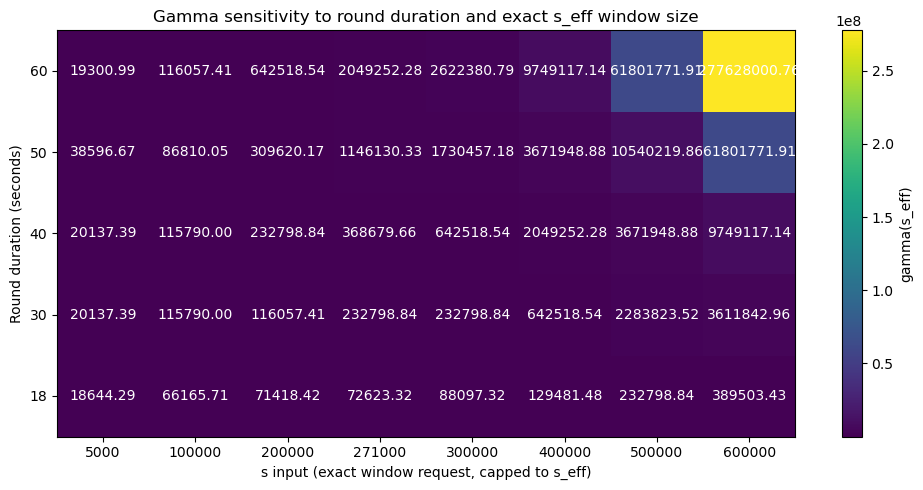

,round_seconds,s_input,s_effective,available_rounds,gamma
0,18,5000,5000,27616921,1.864429e+04
1,18,100000,100000,27616921,6.616571e+04
2,18,200000,200000,27616921,7.141842e+04
3,18,271000,271000,27616921,7.262332e+04
4,18,300000,300000,27616921,8.809732e+04
5,18,400000,400000,27616921,1.294815e+05
6,18,500000,500000,27616921,2.327988e+05
7,18,600000,600000,27616921,3.895034e+05
8,30,5000,5000,16570153,2.013739e+04
9,30,100000,100000,16570153,1.157900e+05


In [13]:
import os
import time
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor

# Sweep round duration and requested s to visualize gamma over exact s_eff windows.
ROUND_SECONDS_GRID = [18, 30, 40, 50, 60]
S_INPUT_GRID = [5000, 100000, 200000, 271000, 300000, 400000, 500000, 600000]

# Toggle parallel execution for the parameter sweep.
USE_PARALLEL = True
MAX_WORKERS = max(1, (os.cpu_count() or 1) - 1)

def build_round_hashrate_for_seconds(round_seconds: int) -> pd.DataFrame:
    """Build a consecutive-round exact hashrate table for a chosen round duration.

    Assigns each block in ``df_valid`` to a round index using floor division:

        round_idx = floor((block_time - genesis_time) / round_seconds)

    Blocks in the same round are averaged. The resulting sparse series is then
    expanded to cover every consecutive round between the first and last observed
    round, and empty rounds are filled via linear interpolation followed by
    forward/backward fill for any remaining edge gaps.

    This function mirrors the logic in cell 12 but accepts an arbitrary
    ``round_seconds`` value so it can be called inside the sensitivity sweep
    without mutating the global ``ROUND_SECONDS`` variable.

    Parameters
    ----------
    round_seconds : int
        Duration of each round in seconds. Must be > 0.

    Returns
    -------
    pd.DataFrame
        A DataFrame with columns ``round_idx`` (int) and ``hashrate_hs_exact``
        (float), indexed 0 … N-1, where N = max_round - min_round + 1. No NaN
        values remain after the fill step.
    """
    tmp = df_valid.copy()
    tmp['round_idx'] = ((tmp['time'] - genesis_time) // round_seconds).astype(int)

    observed = (
        tmp.groupby('round_idx', as_index=False)
        .agg(hashrate_hs_exact=('hashrate_hs_exact', 'mean'))
        .sort_values('round_idx')
        .reset_index(drop=True)
    )

    full_index = pd.RangeIndex(
        int(observed['round_idx'].min()),
        int(observed['round_idx'].max()) + 1,
        name='round_idx',
    )
    completed = observed.set_index('round_idx').reindex(full_index)
    completed['hashrate_hs_exact'] = pd.to_numeric(
        completed['hashrate_hs_exact'], errors='coerce'
    )
    completed['hashrate_hs_exact'] = completed['hashrate_hs_exact'].interpolate(method='linear')
    completed['hashrate_hs_exact'] = completed['hashrate_hs_exact'].ffill().bfill()
    return completed.reset_index()

def compute_one_combination(task: tuple[int, int, dict[int, pd.DataFrame]]) -> dict[str, float | int]:
    """Compute one gamma row for (round_seconds, s_input) using exact s_eff windows.

    Looks up the pre-built consecutive-round hashrate series for ``round_seconds``
    and computes gamma with ``gamma_for_s_hashrate``. Internally, that function
    evaluates exact windows of length ``s_eff = min(s_input, available_rounds)``.

    Parameters
    ----------
    task : tuple[int, int, dict[int, pd.DataFrame]]
        A 3-tuple of:
        - ``round_seconds`` (int): round duration used to look up the hashrate series.
        - ``s_value`` (int): requested window length passed to ``gamma_for_s_hashrate``.
        - ``series_map`` (dict): mapping from round_seconds to the corresponding
          consecutive-round hashrate DataFrame produced by
          ``build_round_hashrate_for_seconds``.

    Returns
    -------
    dict[str, float | int]
        A row dict with keys ``round_seconds``, ``s_input``, ``s_effective``,
        ``available_rounds``, and ``gamma``.
    """
    round_seconds, s_value, series_map = task
    local_round_hashrate = series_map[round_seconds]
    available_rounds = len(local_round_hashrate)
    gamma_value, _, _ = gamma_for_s_hashrate(
        local_round_hashrate['hashrate_hs_exact'], s_value
    )
    return {
        'round_seconds': round_seconds,
        's_input': s_value,
        's_effective': min(s_value, available_rounds),
        'available_rounds': available_rounds,
        'gamma': gamma_value,
    }

# Precompute one round-hashrate series per round_seconds value.
start = time.perf_counter()
if USE_PARALLEL and len(ROUND_SECONDS_GRID) > 1:
    with ThreadPoolExecutor(max_workers=min(MAX_WORKERS, len(ROUND_SECONDS_GRID))) as executor:
        precomputed_list = list(executor.map(build_round_hashrate_for_seconds, ROUND_SECONDS_GRID))
    round_series_map = dict(zip(ROUND_SECONDS_GRID, precomputed_list))
else:
    round_series_map = {
        rs: build_round_hashrate_for_seconds(rs) for rs in ROUND_SECONDS_GRID
    }

# Build tasks for each combination (round_seconds, s_input).
combination_tasks = [
    (rs, s, round_series_map)
    for rs in ROUND_SECONDS_GRID
    for s in S_INPUT_GRID
]

# Parallelize at the combination level.
if USE_PARALLEL and len(combination_tasks) > 1:
    with ThreadPoolExecutor(max_workers=min(MAX_WORKERS, len(combination_tasks))) as executor:
        gamma_grid_rows = list(executor.map(compute_one_combination, combination_tasks))
else:
    gamma_grid_rows = [compute_one_combination(task) for task in combination_tasks]

elapsed = time.perf_counter() - start
print(f'Gamma sweep done in {elapsed:.2f}s (parallel={USE_PARALLEL}, workers={MAX_WORKERS})')
print(f'Computed combinations: {len(combination_tasks)}')
print('Definition: gamma uses exact windows of size s_eff = min(s_input, available_rounds).')

gamma_grid = pd.DataFrame(gamma_grid_rows)
gamma_heatmap = gamma_grid.pivot(index='round_seconds', columns='s_input', values='gamma')

fig, ax = plt.subplots(figsize=(10, 5))
image = ax.imshow(gamma_heatmap.values, aspect='auto', origin='lower')
ax.set_xticks(range(len(gamma_heatmap.columns)))
ax.set_xticklabels(gamma_heatmap.columns)
ax.set_yticks(range(len(gamma_heatmap.index)))
ax.set_yticklabels(gamma_heatmap.index)
ax.set_xlabel('s input (exact window request, capped to s_eff)')
ax.set_ylabel('Round duration (seconds)')
ax.set_title('Gamma sensitivity to round duration and exact s_eff window size')

for row_idx in range(len(gamma_heatmap.index)):
    for col_idx in range(len(gamma_heatmap.columns)):
        value = gamma_heatmap.iloc[row_idx, col_idx]
        ax.text(col_idx, row_idx, f'{value:.2f}', ha='center', va='center', color='white')

fig.colorbar(image, ax=ax, label='gamma(s_eff)')
plt.tight_layout()
plt.savefig('gamma-sensitivity-round-duration-vs-s.pdf', format='pdf')
plt.show()

gamma_grid

### Alternative estimator: cumulative work over a fixed 2-month window

This section keeps the same target window (`S_INPUT * ROUND_SECONDS`) but estimates hashrate from **total expected work** over that window, instead of per-block `1/delta_t` point estimates.

Why this is not cheating:
- It uses the same on-chain data (`difficulty`, `time`).
- It targets the same physical quantity (hashes/second).
- It reduces Poisson luck noise by averaging work over time, which is statistically more stable.

We report both:
- Extreme ratio: `max(window_avg_hashrate) / min(window_avg_hashrate)`
- Robust ratio: `q95(window_avg_hashrate) / q05(window_avg_hashrate)`

In [14]:
# Smoothed hashrate: rolling window of K_SMOOTH blocks (~14 days), then gamma on the round series.
# This removes per-block Poisson luck noise without collapsing the entire history into one number.

K_SMOOTH = 2016  # Bitcoin difficulty adjustment period: ~14 days

smooth_df = df_valid[['time', 'difficulty']].copy().sort_values('time').reset_index(drop=True)
smooth_df['expected_hashes'] = smooth_df['difficulty'] * C_EXACT

# Total expected work over a K_SMOOTH-block window.
smooth_df['roll_work'] = smooth_df['expected_hashes'].rolling(window=K_SMOOTH, min_periods=K_SMOOTH).sum()
# Wall-clock time elapsed over that same window.
smooth_df['roll_time'] = smooth_df['time'] - smooth_df['time'].shift(K_SMOOTH)
# Average hashrate over the K_SMOOTH-block window (hashes/s).
smooth_df['hashrate_smooth'] = smooth_df['roll_work'] / smooth_df['roll_time']
smooth_df = smooth_df.dropna(subset=['hashrate_smooth', 'roll_time'])
smooth_df = smooth_df[smooth_df['roll_time'] > 0].reset_index(drop=True)

# Map to the same 18-second round grid.
smooth_df['round_idx'] = ((smooth_df['time'] - genesis_time) // ROUND_SECONDS).astype(int)
smooth_round = (
    smooth_df.groupby('round_idx', as_index=False)
    .agg(hashrate_smooth=('hashrate_smooth', 'mean'))
    .sort_values('round_idx')
    .reset_index(drop=True)
)

full_idx = pd.RangeIndex(
    int(smooth_round['round_idx'].min()),
    int(smooth_round['round_idx'].max()) + 1,
    name='round_idx',
)
smooth_round = smooth_round.set_index('round_idx').reindex(full_idx)
smooth_round['hashrate_smooth'] = (
    pd.to_numeric(smooth_round['hashrate_smooth'], errors='coerce')
    .interpolate(method='linear').ffill().bfill()
)
smooth_round = smooth_round.reset_index()

gamma_smooth, w_smooth, end_smooth = gamma_for_s_hashrate(smooth_round['hashrate_smooth'], S_INPUT)

print(f'Smoothing window: {K_SMOOTH} blocks (~14 days)')
print(f'Round series length after smoothing: {len(smooth_round):,}')
print(f'')
print(f'Original gamma (noisy per-round point estimates): {gamma_abs:.6f}')
print(f'Smoothed gamma ({K_SMOOTH}-block window, same max/min logic): {gamma_smooth:.6f}')

Smoothing window: 2016 blocks (~14 days)
Round series length after smoothing: 27,528,297

Original gamma (noisy per-round point estimates): 72623.316972
Smoothed gamma (2016-block window, same max/min logic): 31.909972


Smoothed sweep done in 11.85s  (K_SMOOTH=2016)


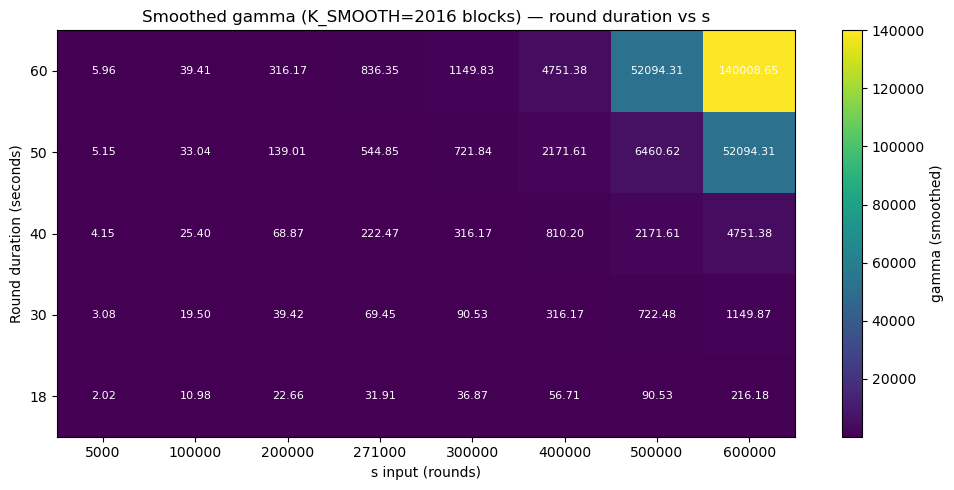

,round_seconds,s_input,s_effective,available_rounds,gamma
0,18,5000,5000,27528297,2.015638
1,18,100000,100000,27528297,10.979209
2,18,200000,200000,27528297,22.660389
3,18,271000,271000,27528297,31.909972
4,18,300000,300000,27528297,36.867462
5,18,400000,400000,27528297,56.710776
6,18,500000,500000,27528297,90.527599
7,18,600000,600000,27528297,216.180699
8,30,5000,5000,16516978,3.075922
9,30,100000,100000,16516978,19.501153


In [15]:
import time as time_module
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor

# Grid sweep with the smoothed estimator (K_SMOOTH-block rolling window).
# For each (round_seconds, s_input) pair, we:
#   1. Build a per-block smoothed hashrate series (same K_SMOOTH).
#   2. Map to the round grid for that round_seconds.
#   3. Apply gamma_for_s_hashrate as usual.

def build_smooth_round_hashrate(round_seconds: int, k_smooth: int = K_SMOOTH) -> pd.DataFrame:
    """Smoothed-estimator version of build_round_hashrate_for_seconds.

    Parameters
    ----------
    round_seconds : int
        Round duration in seconds.
    k_smooth : int
        Number of blocks for the rolling-work smoothing window.

    Returns
    -------
    pd.DataFrame
        Columns: round_idx (int), hashrate_smooth (float). No NaNs.
    """
    tmp = df_valid[['time', 'difficulty']].copy().sort_values('time').reset_index(drop=True)
    tmp['expected_hashes'] = tmp['difficulty'] * C_EXACT
    tmp['roll_work'] = tmp['expected_hashes'].rolling(window=k_smooth, min_periods=k_smooth).sum()
    tmp['roll_time'] = tmp['time'] - tmp['time'].shift(k_smooth)
    tmp['hashrate_smooth'] = tmp['roll_work'] / tmp['roll_time']
    tmp = tmp.dropna(subset=['hashrate_smooth', 'roll_time'])
    tmp = tmp[tmp['roll_time'] > 0].reset_index(drop=True)

    tmp['round_idx'] = ((tmp['time'] - genesis_time) // round_seconds).astype(int)
    observed = (
        tmp.groupby('round_idx', as_index=False)
        .agg(hashrate_smooth=('hashrate_smooth', 'mean'))
        .sort_values('round_idx')
        .reset_index(drop=True)
    )

    full_index = pd.RangeIndex(
        int(observed['round_idx'].min()),
        int(observed['round_idx'].max()) + 1,
        name='round_idx',
    )
    completed = observed.set_index('round_idx').reindex(full_index)
    completed['hashrate_smooth'] = (
        pd.to_numeric(completed['hashrate_smooth'], errors='coerce')
        .interpolate(method='linear').ffill().bfill()
    )
    return completed.reset_index()

def compute_smooth_combination(task):
    round_seconds, s_value, series_map = task
    local = series_map[round_seconds]
    available_rounds = len(local)
    gamma_value, _, _ = gamma_for_s_hashrate(local['hashrate_smooth'], s_value)
    return {
        'round_seconds': round_seconds,
        's_input': s_value,
        's_effective': min(s_value, available_rounds),
        'available_rounds': available_rounds,
        'gamma': gamma_value,
    }

# Precompute smoothed series for each round_seconds.
t0 = time_module.perf_counter()
if USE_PARALLEL and len(ROUND_SECONDS_GRID) > 1:
    with ThreadPoolExecutor(max_workers=min(MAX_WORKERS, len(ROUND_SECONDS_GRID))) as ex:
        smooth_series_list = list(ex.map(build_smooth_round_hashrate, ROUND_SECONDS_GRID))
    smooth_series_map = dict(zip(ROUND_SECONDS_GRID, smooth_series_list))
else:
    smooth_series_map = {rs: build_smooth_round_hashrate(rs) for rs in ROUND_SECONDS_GRID}

smooth_tasks = [(rs, s, smooth_series_map) for rs in ROUND_SECONDS_GRID for s in S_INPUT_GRID]

if USE_PARALLEL and len(smooth_tasks) > 1:
    with ThreadPoolExecutor(max_workers=min(MAX_WORKERS, len(smooth_tasks))) as ex:
        smooth_grid_rows = list(ex.map(compute_smooth_combination, smooth_tasks))
else:
    smooth_grid_rows = [compute_smooth_combination(t) for t in smooth_tasks]

print(f'Smoothed sweep done in {time_module.perf_counter()-t0:.2f}s  (K_SMOOTH={K_SMOOTH})')

smooth_gamma_grid = pd.DataFrame(smooth_grid_rows)
smooth_gamma_heatmap = smooth_gamma_grid.pivot(index='round_seconds', columns='s_input', values='gamma')

fig, ax = plt.subplots(figsize=(10, 5))
image = ax.imshow(smooth_gamma_heatmap.values, aspect='auto', origin='lower')
ax.set_xticks(range(len(smooth_gamma_heatmap.columns)))
ax.set_xticklabels(smooth_gamma_heatmap.columns)
ax.set_yticks(range(len(smooth_gamma_heatmap.index)))
ax.set_yticklabels(smooth_gamma_heatmap.index)
ax.set_xlabel('s input (rounds)')
ax.set_ylabel('Round duration (seconds)')
ax.set_title(f'Smoothed gamma (K_SMOOTH={K_SMOOTH} blocks) — round duration vs s')

for row_idx in range(len(smooth_gamma_heatmap.index)):
    for col_idx in range(len(smooth_gamma_heatmap.columns)):
        val = smooth_gamma_heatmap.iloc[row_idx, col_idx]
        ax.text(col_idx, row_idx, f'{val:.2f}', ha='center', va='center', color='white', fontsize=8)

fig.colorbar(image, ax=ax, label='gamma (smoothed)')
plt.tight_layout()
plt.savefig('gamma-sensitivity-smoothed.pdf', format='pdf')
plt.show()

smooth_gamma_grid

K_SMOOTH sweep done in 24.15s (round_seconds=18)


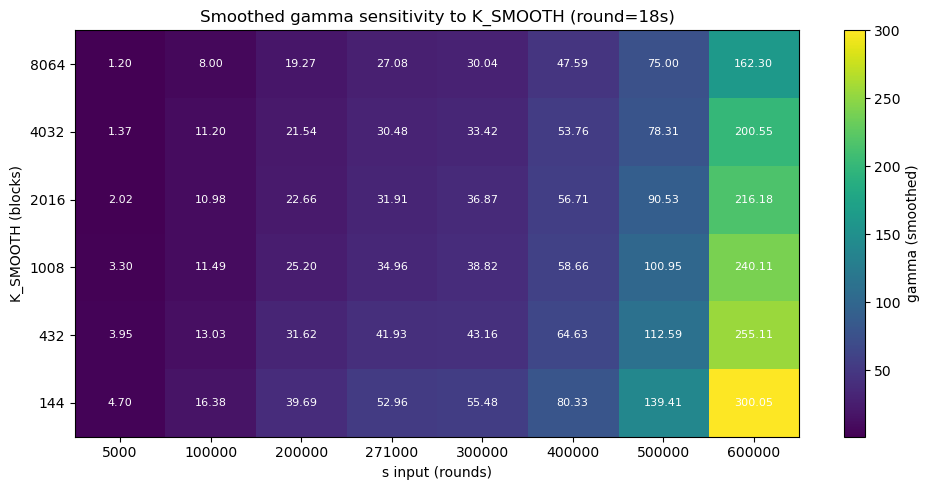

,k_smooth,round_seconds,s_input,s_effective,available_rounds,gamma
0,144,18,5000,5000,27604475,4.702090
1,144,18,100000,100000,27604475,16.379826
2,144,18,200000,200000,27604475,39.694361
3,144,18,271000,271000,27604475,52.964829
4,144,18,300000,300000,27604475,55.480964
5,144,18,400000,400000,27604475,80.334351
6,144,18,500000,500000,27604475,139.407134
7,144,18,600000,600000,27604475,300.051947
8,432,18,5000,5000,27591666,3.947797
9,432,18,100000,100000,27591666,13.025439


In [16]:
import time as time_module
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor

# Sweep K_SMOOTH and s_input for a fixed round duration.
K_SMOOTH_GRID = [144, 432, 1008, 2016, 4032, 8064]  # ~1d, 3d, 7d, 14d, 28d, 56d
ROUND_SECONDS_FIXED = ROUND_SECONDS

def compute_for_one_k(k_smooth: int):
    local_series = build_smooth_round_hashrate(ROUND_SECONDS_FIXED, k_smooth=k_smooth)
    available_rounds = len(local_series)
    rows = []
    for s_value in S_INPUT_GRID:
        gamma_value, _, _ = gamma_for_s_hashrate(local_series['hashrate_smooth'], s_value)
        rows.append({
            'k_smooth': k_smooth,
            'round_seconds': ROUND_SECONDS_FIXED,
            's_input': s_value,
            's_effective': min(s_value, available_rounds),
            'available_rounds': available_rounds,
            'gamma': gamma_value,
        })
    return rows

t0 = time_module.perf_counter()
if USE_PARALLEL and len(K_SMOOTH_GRID) > 1:
    with ThreadPoolExecutor(max_workers=min(MAX_WORKERS, len(K_SMOOTH_GRID))) as ex:
        nested_rows = list(ex.map(compute_for_one_k, K_SMOOTH_GRID))
else:
    nested_rows = [compute_for_one_k(k) for k in K_SMOOTH_GRID]

k_smooth_grid_rows = [row for sublist in nested_rows for row in sublist]
k_smooth_gamma_grid = pd.DataFrame(k_smooth_grid_rows)
k_smooth_heatmap = k_smooth_gamma_grid.pivot(index='k_smooth', columns='s_input', values='gamma')

print(
    f'K_SMOOTH sweep done in {time_module.perf_counter()-t0:.2f}s '
    f'(round_seconds={ROUND_SECONDS_FIXED})'
 )

fig, ax = plt.subplots(figsize=(10, 5))
image = ax.imshow(k_smooth_heatmap.values, aspect='auto', origin='lower')
ax.set_xticks(range(len(k_smooth_heatmap.columns)))
ax.set_xticklabels(k_smooth_heatmap.columns)
ax.set_yticks(range(len(k_smooth_heatmap.index)))
ax.set_yticklabels(k_smooth_heatmap.index)
ax.set_xlabel('s input (rounds)')
ax.set_ylabel('K_SMOOTH (blocks)')
ax.set_title(f'Smoothed gamma sensitivity to K_SMOOTH (round={ROUND_SECONDS_FIXED}s)')

for row_idx in range(len(k_smooth_heatmap.index)):
    for col_idx in range(len(k_smooth_heatmap.columns)):
        val = k_smooth_heatmap.iloc[row_idx, col_idx]
        ax.text(col_idx, row_idx, f'{val:.2f}', ha='center', va='center', color='white', fontsize=8)

fig.colorbar(image, ax=ax, label='gamma (smoothed)')
plt.tight_layout()
plt.savefig('gamma-sensitivity-k-smooth-vs-s.pdf', format='pdf')
plt.show()

k_smooth_gamma_grid

In [17]:
import time as time_module
import numpy as np
import site
import sys
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

# 3D sweep: vary s_input, K_SMOOTH, and round duration simultaneously.
ROUND_SECONDS_3D = [18, 30, 40, 50, 60]
K_SMOOTH_3D = [144, 432, 1008, 2016, 4032, 8064]
S_INPUT_3D = S_INPUT_GRID

if 'build_smooth_round_hashrate' not in globals():
    raise RuntimeError('Run the previous smoothed-grid cell first to define build_smooth_round_hashrate().')

# Ensure user site-packages is visible in this kernel session.
user_site = site.getusersitepackages()
if user_site not in sys.path:
    sys.path.append(user_site)

try:
    import plotly.express as px  # type: ignore[reportMissingImports]
except ImportError:
    raise ImportError(
        "plotly is not available in the current kernel path. "
        "Install it in this kernel, then rerun this cell."
    )

def build_for_pair(pair):
    rs, k = pair
    local_series = build_smooth_round_hashrate(rs, k_smooth=k)
    available_rounds = len(local_series)
    rows = []
    for s in S_INPUT_3D:
        gamma_value, _, _ = gamma_for_s_hashrate(local_series['hashrate_smooth'], s)
        rows.append({
            'round_seconds': rs,
            'k_smooth': k,
            's_input': s,
            's_effective': min(s, available_rounds),
            'available_rounds': available_rounds,
            'gamma': gamma_value,
        })
    return rows

pairs = [(rs, k) for rs in ROUND_SECONDS_3D for k in K_SMOOTH_3D]
t0 = time_module.perf_counter()

if USE_PARALLEL and len(pairs) > 1:
    with ThreadPoolExecutor(max_workers=min(MAX_WORKERS, len(pairs))) as ex:
        nested = list(ex.map(build_for_pair, pairs))
else:
    nested = [build_for_pair(p) for p in pairs]

gamma_3d_rows = [row for sub in nested for row in sub]
gamma_3d_df = pd.DataFrame(gamma_3d_rows)
gamma_3d_df['gamma_log10'] = np.log10(gamma_3d_df['gamma'])

print(
    f'3D sweep done in {time_module.perf_counter()-t0:.2f}s '
    f'for {len(gamma_3d_df):,} points'
 )

fig = px.scatter_3d(
    gamma_3d_df,
    x='s_input',
    y='k_smooth',
    z='round_seconds',
    color='gamma_log10',
    color_continuous_scale='Viridis',
    hover_data={
        'gamma': ':.6f',
        'gamma_log10': ':.4f',
        's_effective': True,
        'available_rounds': True,
    },
    title='Interactive 3D sensitivity (color = log10(gamma))',
)

fig.update_traces(marker=dict(size=5, opacity=0.9))
fig.update_layout(
    scene=dict(
        xaxis_title='s_input (rounds)',
        yaxis_title='K_SMOOTH (blocks)',
        zaxis_title='Round duration (seconds)',
    ),
    coloraxis_colorbar=dict(title='log10(gamma)'),
    margin=dict(l=0, r=0, b=0, t=45),
)

html_path = Path('gamma-3d-interactive.html')
fig.write_html(str(html_path), include_plotlyjs='cdn', auto_open=False)
print(f'Interactive 3D chart saved to: {html_path.resolve()}')

gamma_3d_df.sort_values(['round_seconds', 'k_smooth', 's_input']).reset_index(drop=True)

3D sweep done in 67.44s for 240 points
Interactive 3D chart saved to: /home/miller/Documents/variable-mls/analysis/gamma-3d-interactive.html


,round_seconds,k_smooth,s_input,s_effective,available_rounds,gamma,gamma_log10
0,18,144,5000,5000,27604475,4.702090,0.672291
1,18,144,100000,100000,27604475,16.379826,1.214309
2,18,144,200000,200000,27604475,39.694361,1.598729
3,18,144,271000,271000,27604475,52.964829,1.723988
4,18,144,300000,300000,27604475,55.480964,1.744144
...,...,...,...,...,...,...,...
235,60,8064,271000,271000,8184242,775.534232,2.889601
236,60,8064,300000,300000,8184242,1038.373373,3.016354
237,60,8064,400000,400000,8184242,4146.542413,3.617686
238,60,8064,500000,500000,8184242,39936.569006,4.601371


Reference setup: round_seconds=18, s_input=271000, window_days=56.46
Median block interval in data: 410.00s
Knee candidate: K=1008
Recommended K_SMOOTH: 1008
Recommended K is knee adjusted to stay within <=50% of target window.


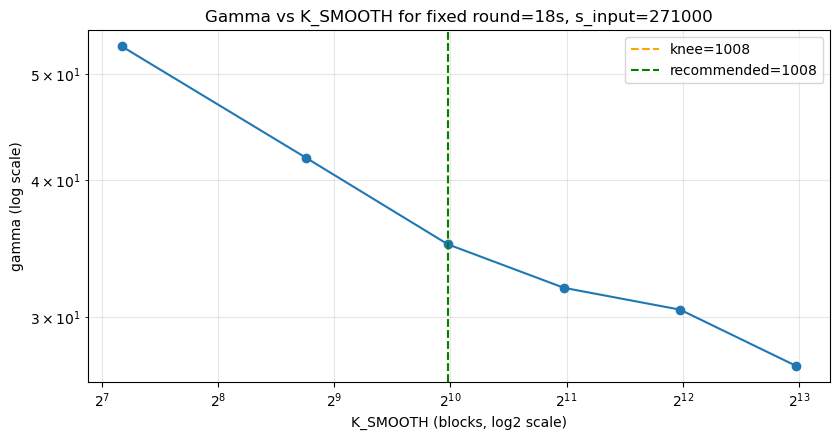

,k_smooth,gamma,smoothing_days_est,smoothing_share_of_window,pct_change_vs_prev
0,144,52.964829,0.683333,0.012103,NaN
1,432,41.930867,2.050000,0.036310,-20.832621
2,1008,34.961995,4.783333,0.084723,-16.619909
3,2016,31.909972,9.566667,0.169446,-8.729546
4,4032,30.481528,19.133333,0.338893,-4.476481
5,8064,27.083362,38.266667,0.677786,-11.148279


In [18]:
# K_SMOOTH selection helper for the fixed research setup (round=18s, s_input=271000).
import numpy as np
import matplotlib.pyplot as plt

ROUND_SECONDS_REF = 18
S_INPUT_REF = 271000
K_GRID_REF = sorted(set(K_SMOOTH_GRID))

if 'build_smooth_round_hashrate' not in globals():
    raise RuntimeError('Run the smoothed-grid cell first to define build_smooth_round_hashrate().')

median_block_seconds = float(df_valid['delta_t'].median())
window_days_ref = (S_INPUT_REF * ROUND_SECONDS_REF) / 86400.0

rows = []
for k in K_GRID_REF:
    local = build_smooth_round_hashrate(ROUND_SECONDS_REF, k_smooth=k)
    gamma_k, _, _ = gamma_for_s_hashrate(local['hashrate_smooth'], S_INPUT_REF)
    smoothing_days = (k * median_block_seconds) / 86400.0
    rows.append({
        'k_smooth': k,
        'gamma': float(gamma_k),
        'smoothing_days_est': smoothing_days,
        'smoothing_share_of_window': smoothing_days / window_days_ref,
    })

k_choice_df = pd.DataFrame(rows).sort_values('k_smooth').reset_index(drop=True)
k_choice_df['pct_change_vs_prev'] = k_choice_df['gamma'].pct_change() * 100.0

# Knee-point heuristic on log-log curve (largest distance to line between endpoints).
x = np.log10(k_choice_df['k_smooth'].to_numpy(dtype=float))
y = np.log10(k_choice_df['gamma'].to_numpy(dtype=float))
x0, y0 = x[0], y[0]
x1, y1 = x[-1], y[-1]
den = np.hypot(y1 - y0, x1 - x0)
if den == 0:
    dist = np.zeros_like(x)
else:
    # Distance from each point to endpoint line in log-log space.
    dist = np.abs((y1 - y0) * x - (x1 - x0) * y + x1 * y0 - y1 * x0) / den
knee_idx = int(np.argmax(dist))
k_knee_value = pd.to_numeric(k_choice_df['k_smooth'], errors='raise').iloc[knee_idx]
k_knee = int(float(k_knee_value))

# Practical cap: avoid smoothing horizon beyond 50% of target gamma window.
valid_cap = k_choice_df[k_choice_df['smoothing_share_of_window'] <= 0.5]
if valid_cap.empty:
    k_recommended = k_knee
    cap_note = 'No K within 50% window cap; using knee directly.'
else:
    k_recommended = int(valid_cap[valid_cap['k_smooth'] >= k_knee]['k_smooth'].min() if (valid_cap['k_smooth'] >= k_knee).any() else valid_cap['k_smooth'].max())
    cap_note = 'Recommended K is knee adjusted to stay within <=50% of target window.'

print(f'Reference setup: round_seconds={ROUND_SECONDS_REF}, s_input={S_INPUT_REF}, window_days={window_days_ref:.2f}')
print(f'Median block interval in data: {median_block_seconds:.2f}s')
print(f'Knee candidate: K={k_knee}')
print(f'Recommended K_SMOOTH: {k_recommended}')
print(cap_note)

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(k_choice_df['k_smooth'], k_choice_df['gamma'], marker='o')
ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.set_xlabel('K_SMOOTH (blocks, log2 scale)')
ax.set_ylabel('gamma (log scale)')
ax.set_title('Gamma vs K_SMOOTH for fixed round=18s, s_input=271000')
ax.grid(True, which='both', alpha=0.3)
ax.axvline(k_knee, color='orange', linestyle='--', label=f'knee={k_knee}')
ax.axvline(k_recommended, color='green', linestyle='--', label=f'recommended={k_recommended}')
ax.legend()
plt.tight_layout()
plt.show()

k_choice_df

### Knee method (quick intuition)

We compute `gamma` for each candidate `K_SMOOTH`, then detect the **knee** on a log-log curve (`log10(K)` vs `log10(gamma)`).

How it works here:
- Draw the straight line between the first and last points of the log-log curve.
- Compute each point's perpendicular distance to that line.
- The point with the largest distance is the knee: it marks the transition from "large gains" to "diminishing returns" when increasing `K_SMOOTH`.

Interpretation:
- Left of knee: increasing `K_SMOOTH` removes a lot of noise.
- Right of knee: extra smoothing gives smaller improvements and can reduce responsiveness.
- We then apply a practical cap (<= 50% of target window) before final recommendation.

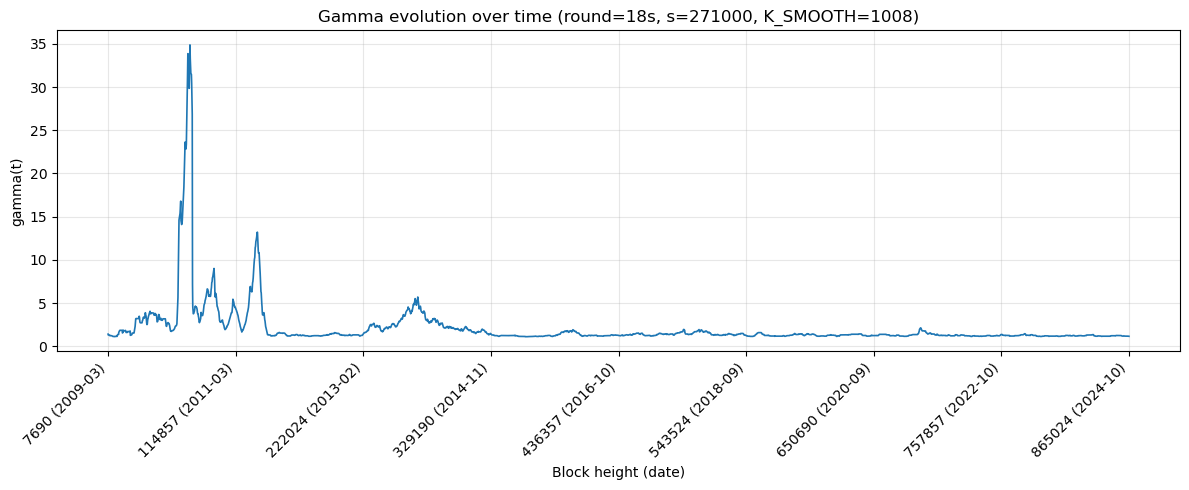

,height_end,date_end,gamma_t
0,7690,2009-03-16 19:39:52+00:00,1.402649
1,7856,2009-03-18 05:47:28+00:00,1.306228
2,8021,2009-03-19 15:45:10+00:00,1.306228
3,8194,2009-03-21 02:06:09+00:00,1.306228
4,8291,2009-03-22 12:20:58+00:00,1.300687
...,...,...,...
3996,864174,2024-10-04 19:02:11+00:00,1.173590
3997,864394,2024-10-06 05:25:33+00:00,1.165636
3998,864613,2024-10-07 15:24:38+00:00,1.159530
3999,864836,2024-10-09 01:41:37+00:00,1.152365


In [21]:
# Gamma evolution over time for fixed parameters.
# Uses the same smoothed estimator and exact-window gamma logic.
import numpy as np
import matplotlib.pyplot as plt

ROUND_SECONDS_TS = 18
S_INPUT_TS = 271000
K_SMOOTH_TS = int(k_recommended) if 'k_recommended' in globals() else K_SMOOTH
PLOT_MAX_POINTS = 4000
EXTRA_XTICKS = 2  # Request a slightly denser x-axis than matplotlib default.

if 'build_smooth_round_hashrate' not in globals():
    raise RuntimeError('Run the smoothed-grid cell first to define build_smooth_round_hashrate().')

series_df = build_smooth_round_hashrate(ROUND_SECONDS_TS, k_smooth=K_SMOOTH_TS)
h = series_df['hashrate_smooth'].dropna().astype(float).reset_index(drop=True)
h = h[h > 0].reset_index(drop=True)

if h.empty:
    raise ValueError('No positive hashrate values available for gamma time series.')

s_eff_ts = min(S_INPUT_TS, len(h))
roll_max = h.rolling(window=s_eff_ts, min_periods=s_eff_ts).max()
roll_min = h.rolling(window=s_eff_ts, min_periods=s_eff_ts).min()
gamma_t = (roll_max / roll_min).dropna().reset_index(drop=True)

# End-round indices in the full round-index space for each gamma_t point.
end_pos = np.arange(s_eff_ts - 1, s_eff_ts - 1 + len(gamma_t), dtype=int)
end_round_idx = series_df.loc[end_pos, 'round_idx'].to_numpy()

# Build round->(height,time) mapping from original block data.
block_meta = df_valid.reset_index().rename(columns={'index': 'height'})[['height', 'time']].copy()
block_meta['round_idx'] = ((block_meta['time'] - genesis_time) // ROUND_SECONDS_TS).astype(int)
round_meta = (
    block_meta.groupby('round_idx', as_index=False)
    .agg(height_end=('height', 'max'), time_end=('time', 'max'))
    .sort_values('round_idx')
    .reset_index(drop=True)
)

# Align metadata to every round in the smoothed series.
meta_aligned = (
    series_df[['round_idx']].merge(round_meta, on='round_idx', how='left')
    .sort_values('round_idx')
    .reset_index(drop=True)
)
meta_aligned['height_end'] = meta_aligned['height_end'].ffill().bfill().astype(int)
meta_aligned['time_end'] = meta_aligned['time_end'].ffill().bfill().astype(int)

height_end = meta_aligned.loc[end_pos, 'height_end'].to_numpy()
date_end = pd.to_datetime(meta_aligned.loc[end_pos, 'time_end'].to_numpy(), unit='s', utc=True)

# Downsample only for plotting readability.
step = max(1, len(gamma_t) // PLOT_MAX_POINTS)
plot_idx = np.arange(0, len(gamma_t), step, dtype=int)

x_plot = height_end[plot_idx]
y_plot = gamma_t.iloc[plot_idx].to_numpy()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(x_plot, y_plot, linewidth=1.2)
ax.set_xlabel('Block height (date)')
ax.set_ylabel('gamma(t)')
ax.set_title(
    f'Gamma evolution over time (round={ROUND_SECONDS_TS}s, s={S_INPUT_TS}, K_SMOOTH={K_SMOOTH_TS})'
 )
ax.grid(True, alpha=0.3)

# Tick labels: "height (YYYY-MM)", inspired by plots.ipynb style.
base_tick_count = max(4, len(ax.get_xticks()))
target_tick_count = base_tick_count + EXTRA_XTICKS
xticks = np.linspace(x_plot.min(), x_plot.max(), num=target_tick_count)
xticks = [int(round(t)) for t in xticks]
xticks = list(dict.fromkeys(xticks))  # Deduplicate after integer rounding while preserving order.

if xticks:
    nearest = [int(np.abs(height_end - x).argmin()) for x in xticks]
    labels = [f"{int(height_end[i])} ({date_end[i].strftime('%Y-%m')})" for i in nearest]
    ax.set_xticks(xticks)
    ax.set_xticklabels(labels, rotation=45, ha='right')

plt.tight_layout()
plt.savefig('gamma-evolution-over-time.pdf', format='pdf')
plt.show()

pd.DataFrame({
    'height_end': height_end,
    'date_end': date_end.astype(str),
    'gamma_t': gamma_t,
}).iloc[::step].reset_index(drop=True)

In [22]:
# Robust gamma: reduce sensitivity to extreme spikes (statistically robust alternative).
# Idea:
# 1) Inside each window, replace max/min by upper/lower quantiles.
# 2) Across windows, replace the global maximum by a high quantile (e.g. 99th percentile).

ROUND_SECONDS_ROB = 18
S_INPUT_ROB = 271000
K_SMOOTH_ROB = int(k_recommended) if 'k_recommended' in globals() else K_SMOOTH
ALPHA_INNER = 0.05        # 5%-95% inside each window (winsorized-style range)
OUTER_QUANTILE = 0.99     # "worst typical" window, less sensitive than absolute max

if 'build_smooth_round_hashrate' not in globals():
    raise RuntimeError('Run the smoothed-grid cell first to define build_smooth_round_hashrate().')

series_rob = build_smooth_round_hashrate(ROUND_SECONDS_ROB, k_smooth=K_SMOOTH_ROB)
h_rob = series_rob['hashrate_smooth'].dropna().astype(float).reset_index(drop=True)
h_rob = h_rob[h_rob > 0].reset_index(drop=True)

if h_rob.empty:
    raise ValueError('No positive values available to compute robust gamma.')

s_eff_rob = min(S_INPUT_ROB, len(h_rob))

# Classical gamma for reference.
gamma_classic_rob_ref, _, _ = gamma_for_s_hashrate(h_rob, S_INPUT_ROB)

# Robust per-window ratio using rolling quantiles instead of max/min.
roll_q_low = h_rob.rolling(window=s_eff_rob, min_periods=s_eff_rob).quantile(ALPHA_INNER)
roll_q_high = h_rob.rolling(window=s_eff_rob, min_periods=s_eff_rob).quantile(1.0 - ALPHA_INNER)
ratio_rob_windows = (roll_q_high / roll_q_low).dropna().reset_index(drop=True)

if ratio_rob_windows.empty:
    raise ValueError('No robust-window ratios computed; check series length and parameters.')

gamma_robust_max = float(ratio_rob_windows.max())
gamma_robust_q = float(ratio_rob_windows.quantile(OUTER_QUANTILE))

# Locate the worst robust window endpoint for diagnostics.
robust_worst_local_end = int(ratio_rob_windows.idxmax())
robust_worst_global_end = robust_worst_local_end + (s_eff_rob - 1)
worst_round_idx = int(series_rob.loc[robust_worst_global_end, 'round_idx'])

# Map this endpoint to block height/date for interpretability.
block_meta_rob = df_valid.reset_index().rename(columns={'index': 'height'})[['height', 'time']].copy()
block_meta_rob['round_idx'] = ((block_meta_rob['time'] - genesis_time) // ROUND_SECONDS_ROB).astype(int)
round_meta_rob = (
    block_meta_rob.groupby('round_idx', as_index=False)
    .agg(height_end=('height', 'max'), time_end=('time', 'max'))
    .sort_values('round_idx')
    .reset_index(drop=True)
)
nearest_meta = round_meta_rob.iloc[(round_meta_rob['round_idx'] - worst_round_idx).abs().argmin()]
worst_height = int(nearest_meta['height_end'])
worst_date = pd.to_datetime(int(nearest_meta['time_end']), unit='s', utc=True)

summary_rob = pd.DataFrame([
    {
        'method': 'classic max/min then global max',
        'value': gamma_classic_rob_ref,
        'inner_quantile_range': '0%-100%',
        'outer_aggregation': 'max',
    },
    {
        'method': 'robust inner quantiles, global max',
        'value': gamma_robust_max,
        'inner_quantile_range': f'{int(ALPHA_INNER*100)}%-{int((1-ALPHA_INNER)*100)}%',
        'outer_aggregation': 'max',
    },
    {
        'method': 'robust inner quantiles, global quantile',
        'value': gamma_robust_q,
        'inner_quantile_range': f'{int(ALPHA_INNER*100)}%-{int((1-ALPHA_INNER)*100)}%',
        'outer_aggregation': f'q{int(OUTER_QUANTILE*100)}',
    },
])

print('Robust gamma setup:')
print(
    f'  round={ROUND_SECONDS_ROB}s, s_input={S_INPUT_ROB}, s_eff={s_eff_rob}, '
    f'K_SMOOTH={K_SMOOTH_ROB}, inner=[{ALPHA_INNER:.0%},{1-ALPHA_INNER:.0%}], outer={OUTER_QUANTILE:.0%}'
)
print('')
print('Interpretation:')
print('  - classic value is ultra-sensitive to one extreme point.')
print('  - robust max still asks for the worst window, but after trimming extremes inside each window.')
print(f'  - robust q{int(OUTER_QUANTILE*100)} is the worst typical window (ignores the most extreme {100*(1-OUTER_QUANTILE):.1f}% windows).')
print('')
print(
    f'Worst robust-max window ends near round_idx={worst_round_idx}, '
    f'height~{worst_height}, date={worst_date.strftime("%Y-%m")}'
)

summary_rob

Robust gamma setup:
  round=18s, s_input=271000, s_eff=271000, K_SMOOTH=1008, inner=[5%,95%], outer=99%

Interpretation:
  - classic value is ultra-sensitive to one extreme point.
  - robust max still asks for the worst window, but after trimming extremes inside each window.
  - robust q99 is the worst typical window (ignores the most extreme 1.0% windows).

Worst robust-max window ends near round_idx=2893121, height~77036, date=2010-08


,method,value,inner_quantile_range,outer_aggregation
0,classic max/min then global max,34.961995,0%-100%,max
1,"robust inner quantiles, global max",30.355086,5%-95%,max
2,"robust inner quantiles, global quantile",9.996305,5%-95%,q99


### Meaning of `inner_quantile_range` and `outer_aggregation`

- `inner_quantile_range`:
  Defines the quantile band used **inside each sliding window** before computing the window ratio.
  Example with `5%-95%`: in each window, we use
  `window_ratio_robust = q95(window) / q05(window)`
  instead of `max(window) / min(window)`. This reduces the impact of isolated spikes or dips.

- `outer_aggregation`:
  Defines how we combine all window-level ratios into one final gamma value.
  - `max`: strict worst-case across all windows.
  - `q99` (or any high quantile): worst *typical* case, ignoring the most extreme windows.

In short:
- `inner_quantile_range` controls robustness **within** each window.
- `outer_aggregation` controls robustness **across** windows.

Robustness sensitivity grid
  setup: round=18s, s_input=271000, s_eff=271000, K_SMOOTH=1008
  classic reference gamma: 34.961995


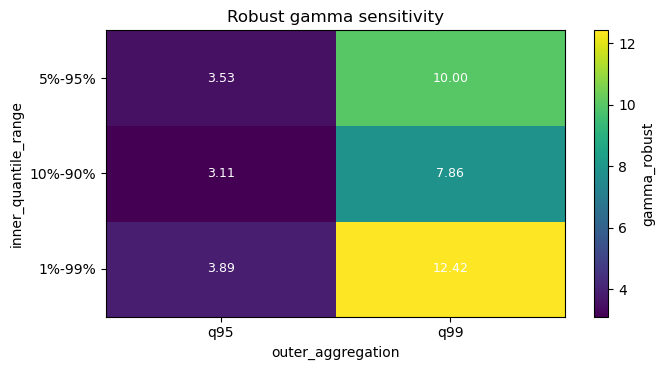

,alpha_inner,inner_quantile_range,outer_quantile,outer_aggregation,gamma_robust,gamma_robust_max,gamma_classic_ref,reduction_vs_classic_pct
0,0.01,1%-99%,0.95,q95,3.888302,33.342730,34.961995,88.878491
1,0.01,1%-99%,0.99,q99,12.419624,33.342730,34.961995,64.476788
2,0.05,5%-95%,0.95,q95,3.528464,30.355086,34.961995,89.907716
3,0.05,5%-95%,0.99,q99,9.996305,30.355086,34.961995,71.408081
4,0.10,10%-90%,0.95,q95,3.112260,26.622140,34.961995,91.098163
5,0.10,10%-90%,0.99,q99,7.861755,26.622140,34.961995,77.513426


In [23]:
# Sensitivity grid for robust gamma definition.
# Goal: compare (inner quantile band) x (outer aggregation quantile).

import matplotlib.pyplot as plt

ROUND_SECONDS_ROB_GRID = 18
S_INPUT_ROB_GRID = 271000
K_SMOOTH_ROB_GRID = int(k_recommended) if 'k_recommended' in globals() else K_SMOOTH

ALPHA_INNER_GRID = [0.01, 0.05, 0.10]   # inner bands: 1-99, 5-95, 10-90
OUTER_QUANTILE_GRID = [0.95, 0.99]      # outer aggregations: q95, q99

if 'build_smooth_round_hashrate' not in globals():
    raise RuntimeError('Run the smoothed-grid cell first to define build_smooth_round_hashrate().')

series_grid = build_smooth_round_hashrate(ROUND_SECONDS_ROB_GRID, k_smooth=K_SMOOTH_ROB_GRID)
h_grid = series_grid['hashrate_smooth'].dropna().astype(float).reset_index(drop=True)
h_grid = h_grid[h_grid > 0].reset_index(drop=True)

if h_grid.empty:
    raise ValueError('No positive values available for robust sensitivity grid.')

s_eff_grid = min(S_INPUT_ROB_GRID, len(h_grid))
gamma_classic_grid_ref, _, _ = gamma_for_s_hashrate(h_grid, S_INPUT_ROB_GRID)

rows = []
for alpha in ALPHA_INNER_GRID:
    q_low = h_grid.rolling(window=s_eff_grid, min_periods=s_eff_grid).quantile(alpha)
    q_high = h_grid.rolling(window=s_eff_grid, min_periods=s_eff_grid).quantile(1.0 - alpha)
    ratios = (q_high / q_low).dropna().reset_index(drop=True)

    if ratios.empty:
        continue

    for outer_q in OUTER_QUANTILE_GRID:
        rows.append({
            'alpha_inner': alpha,
            'inner_quantile_range': f'{int(alpha*100)}%-{int((1-alpha)*100)}%',
            'outer_quantile': outer_q,
            'outer_aggregation': f'q{int(outer_q*100)}',
            'gamma_robust': float(ratios.quantile(outer_q)),
            'gamma_robust_max': float(ratios.max()),
            'gamma_classic_ref': float(gamma_classic_grid_ref),
            'reduction_vs_classic_pct': 100.0 * (1.0 - float(ratios.quantile(outer_q)) / float(gamma_classic_grid_ref)),
        })

robust_grid_df = pd.DataFrame(rows).sort_values(['alpha_inner', 'outer_quantile']).reset_index(drop=True)

if robust_grid_df.empty:
    raise ValueError('Sensitivity grid is empty; check parameters.')

print('Robustness sensitivity grid')
print(
    f'  setup: round={ROUND_SECONDS_ROB_GRID}s, s_input={S_INPUT_ROB_GRID}, '
    f's_eff={s_eff_grid}, K_SMOOTH={K_SMOOTH_ROB_GRID}'
)
print(f'  classic reference gamma: {gamma_classic_grid_ref:.6f}')

pivot = robust_grid_df.pivot(index='inner_quantile_range', columns='outer_aggregation', values='gamma_robust')

fig, ax = plt.subplots(figsize=(7, 3.8))
img = ax.imshow(pivot.values, aspect='auto', origin='lower')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel('outer_aggregation')
ax.set_ylabel('inner_quantile_range')
ax.set_title('Robust gamma sensitivity')

for r in range(len(pivot.index)):
    for c in range(len(pivot.columns)):
        val = pivot.iloc[r, c]
        ax.text(c, r, f'{val:.2f}', ha='center', va='center', color='white', fontsize=9)

fig.colorbar(img, ax=ax, label='gamma_robust')
plt.tight_layout()
plt.show()

robust_grid_df

In [24]:
# Official robust gamma definition for this notebook.
# Convention chosen from the sensitivity grid:
#   inner_quantile_range = 5%-95%
#   outer_aggregation = q99

GAMMA_ROBUST_ALPHA_OFFICIAL = 0.05
GAMMA_ROBUST_OUTER_Q_OFFICIAL = 0.99
GAMMA_ROBUST_LABEL_OFFICIAL = 'q95/q05 inside windows + q99 across windows'

ROUND_SECONDS_OFFICIAL = 18
S_INPUT_OFFICIAL = 271000
K_SMOOTH_OFFICIAL = int(k_recommended) if 'k_recommended' in globals() else K_SMOOTH

series_off = build_smooth_round_hashrate(ROUND_SECONDS_OFFICIAL, k_smooth=K_SMOOTH_OFFICIAL)
h_off = series_off['hashrate_smooth'].dropna().astype(float).reset_index(drop=True)
h_off = h_off[h_off > 0].reset_index(drop=True)

if h_off.empty:
    raise ValueError('No positive values available to compute gamma_robust_official.')

s_eff_off = min(S_INPUT_OFFICIAL, len(h_off))

q_low_off = h_off.rolling(window=s_eff_off, min_periods=s_eff_off).quantile(GAMMA_ROBUST_ALPHA_OFFICIAL)
q_high_off = h_off.rolling(window=s_eff_off, min_periods=s_eff_off).quantile(1.0 - GAMMA_ROBUST_ALPHA_OFFICIAL)
ratio_off = (q_high_off / q_low_off).dropna().reset_index(drop=True)

if ratio_off.empty:
    raise ValueError('No ratios available for gamma_robust_official; check parameters.')

gamma_robust_official = float(ratio_off.quantile(GAMMA_ROBUST_OUTER_Q_OFFICIAL))
gamma_robust_official_max = float(ratio_off.max())
gamma_classic_official_ref, _, _ = gamma_for_s_hashrate(h_off, S_INPUT_OFFICIAL)

gamma_official_summary = pd.DataFrame([
    {
        'metric': 'gamma_classic_reference',
        'value': gamma_classic_official_ref,
    },
    {
        'metric': 'gamma_robust_official',
        'value': gamma_robust_official,
    },
    {
        'metric': 'gamma_robust_official_max_window',
        'value': gamma_robust_official_max,
    },
    {
        'metric': 'reduction_vs_classic_pct',
        'value': 100.0 * (1.0 - gamma_robust_official / gamma_classic_official_ref),
    },
])

print('Official robust gamma definition set.')
print(f'  label: {GAMMA_ROBUST_LABEL_OFFICIAL}')
print(
    f'  setup: round={ROUND_SECONDS_OFFICIAL}s, s_input={S_INPUT_OFFICIAL}, '
    f's_eff={s_eff_off}, K_SMOOTH={K_SMOOTH_OFFICIAL}'
)
print(f'  gamma_robust_official = {gamma_robust_official:.6f}')

gamma_official_summary

Official robust gamma definition set.
  label: q95/q05 inside windows + q99 across windows
  setup: round=18s, s_input=271000, s_eff=271000, K_SMOOTH=1008
  gamma_robust_official = 9.996305


,metric,value
0,gamma_classic_reference,34.961995
1,gamma_robust_official,9.996305
2,gamma_robust_official_max_window,30.355086
3,reduction_vs_classic_pct,71.408081
